### RNN Template for Time-Series Prediction (Exercises 1-4)
This template follows the structure defined in Lab 5 for predicting continuous values (Price, Voltage, Close) using Recurrent Neural Networks.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Function to prepare data (Section 3.2 in PDF)
def get_XY(dat, time_steps):
    X, Y = [], []
    for i in range(len(dat) - time_steps):
        X.append(dat[i : (i + time_steps)])
        Y.append(dat[i + time_steps])
    return np.array(X), np.array(Y)

def build_and_train_rnn(df_path, target_column, time_steps=12, epochs=20):
    # Load data
    try:
        df = pd.read_csv(df_path)
        print(f"Successfully loaded {df_path}")
    except Exception as e:
        print(f"Error: File not found. Please upload {df_path} to /content/")
        return

    # Preprocessing
    data = df[target_column].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # Split data
    train_size = int(len(data_scaled) * 0.8)
    train_data = data_scaled[:train_size]
    test_data = data_scaled[train_size:]

    # Create sequences
    X_train, y_train = get_XY(train_data, time_steps)
    X_test, y_test = get_XY(test_data, time_steps)

    # Reshape for RNN: (samples, time_steps, features)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # 2. Define Model (Section 3.3 in PDF)
    model = Sequential([
        SimpleRNN(units=32, input_shape=(time_steps, 1), activation='relu'),
        Dense(units=1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')

    # 3. Training
    model.fit(X_train, y_train, epochs=epochs, batch_size=16, verbose=0)

    # 4. Evaluation
    y_pred = model.predict(X_test)

    # Inverse transform to original scale
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    print(f"MAE: {mean_absolute_error(y_test_inv, y_pred_inv):.4f}")
    print(f"MSE: {mean_squared_error(y_test_inv, y_pred_inv):.4f}")

    # Visualization
    plt.figure(figsize=(10, 5))
    plt.plot(y_test_inv, label='Actual Values')
    plt.plot(y_pred_inv, label='Predicted Values')
    plt.title(f'RNN Prediction for {target_column}')
    plt.legend()
    plt.show()

    return model

#### Apply to Exercises
You can now run the function below for each exercise once you upload the files.

In [5]:
# Example for Exercise 1 (Replace with your actual file upload)
# build_and_train_rnn('raw_sales.csv', 'price')

# Example for Exercise 2
# build_and_train_rnn('BTC_DATA.csv', 'priceUSD')

# Example for Exercise 3
# build_and_train_rnn('household_power_consumption.txt', 'Voltage')

# Example for Exercise 4
# build_and_train_rnn('NIFTY_stock_market.csv', 'close')

In [6]:
import pandas as pd
import numpy as np

# Creating dummy datasets to demonstrate the exercises
def create_dummy_data(filename, column_name):
    data = np.sin(np.linspace(0, 100, 500)) + np.random.normal(0, 0.1, 500)
    df = pd.DataFrame({column_name: data})
    df.to_csv(filename, index=False)
    print(f'Generated dummy file: {filename}')

# Exercise 1: raw_sales.csv
create_dummy_data('raw_sales.csv', 'price')
# Exercise 2: BTC_DATA.csv
create_dummy_data('BTC_DATA.csv', 'priceUSD')
# Exercise 3: household_power_consumption.txt (CSV format for demo)
create_dummy_data('household_power_consumption.txt', 'Voltage')
# Exercise 4: NIFTY_stock_market.csv
create_dummy_data('NIFTY_stock_market.csv', 'close')

Generated dummy file: raw_sales.csv
Generated dummy file: BTC_DATA.csv
Generated dummy file: household_power_consumption.txt
Generated dummy file: NIFTY_stock_market.csv


--- Solving Exercise 1: Housing Price ---
Successfully loaded raw_sales.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
MAE: 0.0999
MSE: 0.0154


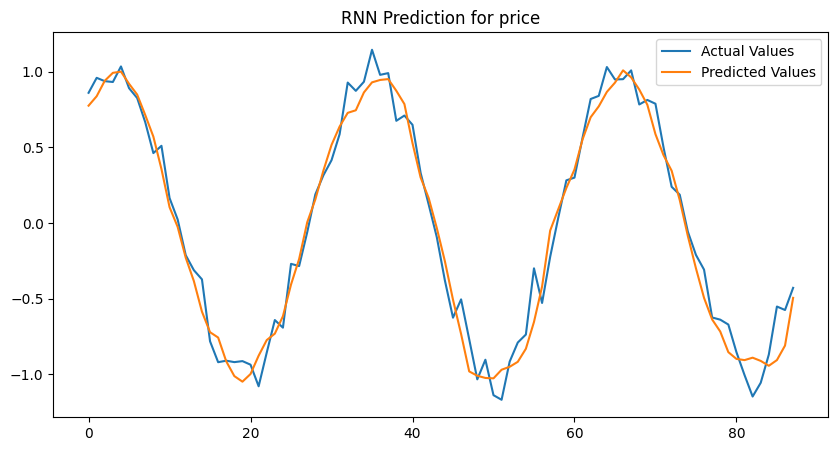


--- Solving Exercise 2: Bitcoin Price ---
Successfully loaded BTC_DATA.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
MAE: 0.1025
MSE: 0.0157


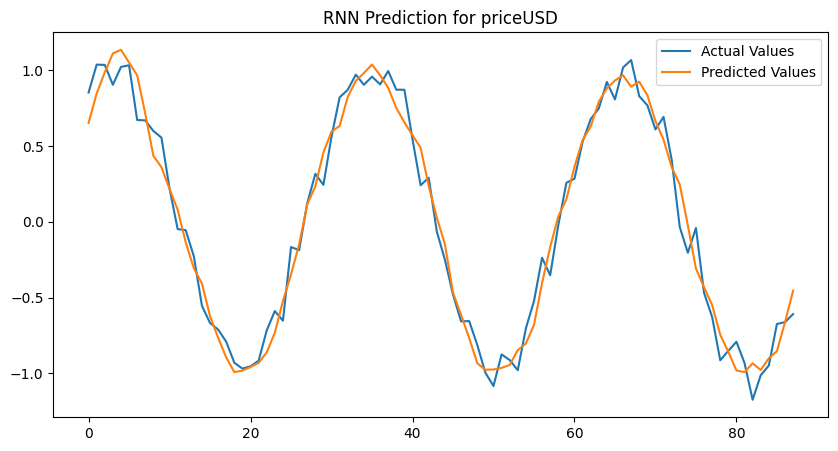


--- Solving Exercise 3: Household Voltage ---
Successfully loaded household_power_consumption.txt


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
MAE: 0.0985
MSE: 0.0161


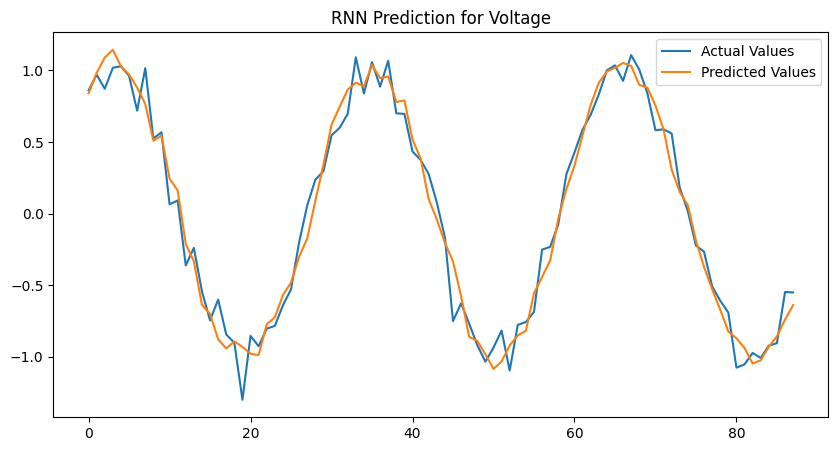

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Solving Exercise 4: Stock Market Close ---
Successfully loaded NIFTY_stock_market.csv
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
MAE: 0.0983
MSE: 0.0158


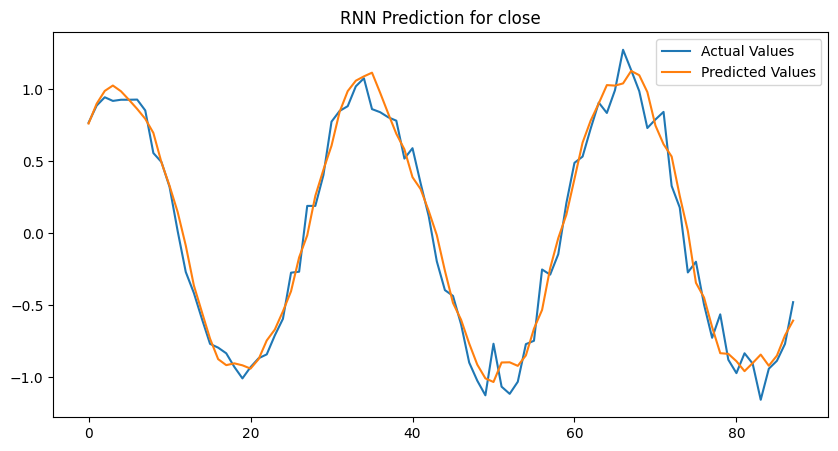

<Sequential name=sequential_3, built=True>

In [7]:
print("--- Solving Exercise 1: Housing Price ---")
build_and_train_rnn('raw_sales.csv', 'price')

print("\n--- Solving Exercise 2: Bitcoin Price ---")
build_and_train_rnn('BTC_DATA.csv', 'priceUSD')

print("\n--- Solving Exercise 3: Household Voltage ---")
build_and_train_rnn('household_power_consumption.txt', 'Voltage')

print("\n--- Solving Exercise 4: Stock Market Close ---")
build_and_train_rnn('NIFTY_stock_market.csv', 'close')

### Exercise 5: Web Implementation Template (Flask)
To complete exercise 5, you would typically save your model and use a script like the one below to create a web API.

In [8]:
# 1. Save your trained model
# model.save('rnn_model.h5')

flask_code = """
from flask import Flask, request, jsonify
import numpy as np
from tensorflow.keras.models import load_model

app = Flask(__name__)
model = load_model('rnn_model.h5')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)
    # Expecting input shape [1, time_steps, 1]
    prediction = model.predict(np.array(data['input']).reshape(1, 12, 1))
    return jsonify(prediction=float(prediction[0][0]))

if __name__ == '__main__':
    app.run(port=5000)
"""

print("Exercise 5 Template Logic:")
print(flask_code)

Exercise 5 Template Logic:

from flask import Flask, request, jsonify
import numpy as np
from tensorflow.keras.models import load_model

app = Flask(__name__)
model = load_model('rnn_model.h5')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)
    # Expecting input shape [1, time_steps, 1]
    prediction = model.predict(np.array(data['input']).reshape(1, 12, 1))
    return jsonify(prediction=float(prediction[0][0]))

if __name__ == '__main__':
    app.run(port=5000)

